# Airbnb Price Prediction Analysis

This notebook follows the project outline and milestone report for the Airbnb price prediction regression project. It covers:

- data loading and cleaning
- exploratory data analysis
- baseline models
- regression modeling
- cross-validation
- final evaluation and interpretation

**Dataset expected:** U.S. Airbnb Open Data from Kaggle.

Update the `DATA_PATH` below to point to your CSV file before running. This notebook was structured from the team outline and milestone report. fileciteturn0file1 fileciteturn0file2L1-L20

In [ ]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    train_test_split, cross_validate, KFold, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

## 1. Configuration

The report frames this as a **regression** problem with **price** as the continuous target, using listing, review, host, and geographic features. It also notes a right-skewed price distribution, missing review-related fields, and the need to clean price strings. fileciteturn0file2L21-L97

In [8]:
# Change this to your local CSV path
DATA_PATH = "AB_US_2023.csv"

# Toggle these depending on your experiment
USE_LOG_TARGET = True
REMOVE_EXTREME_OUTLIERS = True
OUTLIER_UPPER_QUANTILE = 0.99

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

## 2. Load data

In [9]:
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(
        f"Could not find dataset at {DATA_PATH}. "
        "Download the Kaggle CSV and update DATA_PATH before running."
    )

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (122001, 18)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city
0,958,"Bright, Modern Garden Unit - 1BR/1BTH",1169,Holly,NaN,Western Addition,37.77028,-122.43317,Entire home/apt,202.0,2.0,383.0,2023-02-19,2.31,1.0,128.0,59.0,San Francisco
1,5858,Creative Sanctuary,8904,Philip And Tania,NaN,Bernal Heights,37.74474,-122.42089,Entire home/apt,235.0,30.0,111.0,2017-08-06,0.66,1.0,365.0,0.0,San Francisco
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,NaN,Haight Ashbury,37.76555,-122.45213,Private room,56.0,32.0,9.0,2022-10-27,0.09,13.0,365.0,1.0,San Francisco
3,8339,Historic Alamo Square Victorian,24215,Rosy,NaN,Western Addition,37.77564,-122.43642,Entire home/apt,575.0,9.0,28.0,2019-06-28,0.17,2.0,365.0,0.0,San Francisco
4,8739,"Mission Sunshine, with Private Bath",7149,Ivan & Wendy,NaN,Mission,37.76030,-122.42197,Private room,110.0,1.0,770.0,2023-02-25,4.65,2.0,159.0,34.0,San Francisco


## 3. Inspect columns and basic info

In [10]:
print(df.columns.tolist())
print()
df.info()

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'city']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122001 entries, 0 to 122000
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              122001 non-null  int64  
 1   name                            121986 non-null  object 
 2   host_id                         122001 non-null  int64  
 3   host_name                       121993 non-null  object 
 4   neighbourhood_group             85382 non-null   object 
 5   neighbourhood                   122000 non-null  object 
 6   latitude                        122000 non-null  float64
 7   longitude                       12200

In [11]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,122001.0,NaN,NaN,NaN,234806808610461568.0,338810430561923072.0,109.0,22555142.0,45933557.0,641644631734165504.0,856071734230683136.0
name,121986,115685,Presidential Suite In A Mansion,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,122001.0,NaN,NaN,NaN,151679434.385161,157595772.247843,521.0,19303369.0,89501678.0,260074787.0,506668910.0
host_name,121993,19192,Blueground,2297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,85382,8,City of Los Angeles,22204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,122000,811,Bedford-Stuyvesant,3086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,122000.0,NaN,NaN,NaN,37.161277,3.419285,29.89702,34.07799,37.75321,40.70261,44.99723
longitude,122000.0,NaN,NaN,NaN,-97.21229,21.742745,-123.08913,-118.389388,-90.082501,-73.973858,-71.072397
room_type,122000,4,Entire home/apt,80331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,122000.0,NaN,NaN,NaN,237.634869,977.622561,0.0,85.0,135.0,223.0,99999.0


## 4. Utility helpers

The dataset version can vary a bit across uploads, so these helpers try to locate expected columns by common aliases.

In [12]:
def first_existing_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def clean_price_series(series: pd.Series) -> pd.Series:
    # Handles strings like "$123.00", "$1,250", "125"
    return (
        series.astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        .astype(float)
    )

def add_missing_review_indicators(df: pd.DataFrame, rpm_col: str | None, last_review_col: str | None) -> pd.DataFrame:
    out = df.copy()
    if rpm_col and rpm_col in out.columns:
        out["has_reviews_per_month"] = out[rpm_col].notna().astype(int)
    if last_review_col and last_review_col in out.columns:
        out["has_last_review"] = out[last_review_col].notna().astype(int)
    return out

## 5. Identify target and candidate features

In [ ]:
price_col = first_existing_column(df.columns, ["price"])
city_col = first_existing_column(df.columns, ["city"])
lat_col = first_existing_column(df.columns, ["latitude", "lat"])
lon_col = first_existing_column(df.columns, ["longitude", "long", "lng"])
room_type_col = first_existing_column(df.columns, ["room_type"])
minimum_nights_col = first_existing_column(df.columns, ["minimum_nights"])
availability_col = first_existing_column(df.columns, ["availability_365"])
reviews_col = first_existing_column(df.columns, ["number_of_reviews"])
reviews_pm_col = first_existing_column(df.columns, ["reviews_per_month"])
reviews_ltm_col = first_existing_column(df.columns, ["number_of_reviews_ltm"])
host_listings_col = first_existing_column(df.columns, ["calculated_host_listings_count"])
neighborhood_col = first_existing_column(df.columns, ["neighbourhood", "neighborhood"])
neighborhood_group_col = first_existing_column(df.columns, ["neighbourhood_group", "neighborhood_group"])
last_review_col = first_existing_column(df.columns, ["last_review"])

assert price_col is not None, "Could not find a price column."

# NOTE: neighbourhood (811 unique) is NOT included as a direct feature to avoid
# a massive one-hot-encoded matrix. Instead we frequency-encode it in the
# feature engineering step (neighbourhood_freq).
candidate_features = [
    city_col,
    neighborhood_group_col,
    room_type_col,
    lat_col,
    lon_col,
    minimum_nights_col,
    availability_col,
    reviews_col,
    reviews_pm_col,
    reviews_ltm_col,
    host_listings_col,
]
candidate_features = [c for c in candidate_features if c is not None]

print("Target:", price_col)
print("Candidate features:", candidate_features)
print(f"(neighbourhood will be frequency-encoded separately — {df[neighborhood_col].nunique()} unique values)")

## 6. Clean target and basic preprocessing

This follows the report's plan:
- convert price from string to numeric
- account for missing review fields
- optionally remove extreme outliers
- optionally model `log(price)` because price is strongly right-skewed fileciteturn0file2L70-L97

In [ ]:
df = df.copy()

# Clean target
df[price_col] = clean_price_series(df[price_col])

# Add simple missingness indicators for review fields
df = add_missing_review_indicators(df, reviews_pm_col, last_review_col)

# --- Feature engineering ---
# Log-transform right-skewed numeric features to reduce outlier influence
for col in [minimum_nights_col, reviews_col, reviews_ltm_col, host_listings_col]:
    if col and col in df.columns:
        df[f"log1p_{col}"] = np.log1p(df[col])

# Frequency-encode neighbourhood (811 unique values → OHE would create too many columns)
if neighborhood_col and neighborhood_col in df.columns:
    neigh_freq = df[neighborhood_col].value_counts(normalize=True)
    df["neighbourhood_freq"] = df[neighborhood_col].map(neigh_freq)

# Extract review recency (days since last review) as a numeric feature
if last_review_col and last_review_col in df.columns:
    df["last_review_date"] = pd.to_datetime(df[last_review_col], errors="coerce")
    ref_date = df["last_review_date"].max()
    df["days_since_last_review"] = (ref_date - df["last_review_date"]).dt.days
    df.drop(columns=["last_review_date"], inplace=True)

# Keep only target + chosen features
extra_indicator_cols = [c for c in ["has_reviews_per_month", "has_last_review"] if c in df.columns]
engineered_cols = [c for c in [
    "log1p_minimum_nights", "log1p_number_of_reviews",
    "log1p_number_of_reviews_ltm", "log1p_calculated_host_listings_count",
    "neighbourhood_freq", "days_since_last_review"
] if c in df.columns]

model_df = df[[price_col] + candidate_features + extra_indicator_cols + engineered_cols].copy()

# Drop rows without a valid target
model_df = model_df.dropna(subset=[price_col])

# Remove non-positive prices if present
model_df = model_df[model_df[price_col] > 0].copy()

# Optional outlier trimming
if REMOVE_EXTREME_OUTLIERS:
    upper = model_df[price_col].quantile(OUTLIER_UPPER_QUANTILE)
    model_df = model_df[model_df[price_col] <= upper].copy()
    print(f"Removed prices above {OUTLIER_UPPER_QUANTILE:.0%} quantile: {upper:.2f}")

print("Cleaned shape:", model_df.shape)
print(f"Engineered features added: {engineered_cols}")
model_df.head()

## 7. Missing values overview

In [15]:
missing_summary = (
    model_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)
missing_summary

,missing_fraction
neighbourhood_group,0.301411
reviews_per_month,0.229837
price,0.000000
neighbourhood,0.000000
room_type,0.000000
latitude,0.000000
city,0.000000
longitude,0.000000
minimum_nights,0.000000
availability_365,0.000000


## 8. Exploratory data analysis

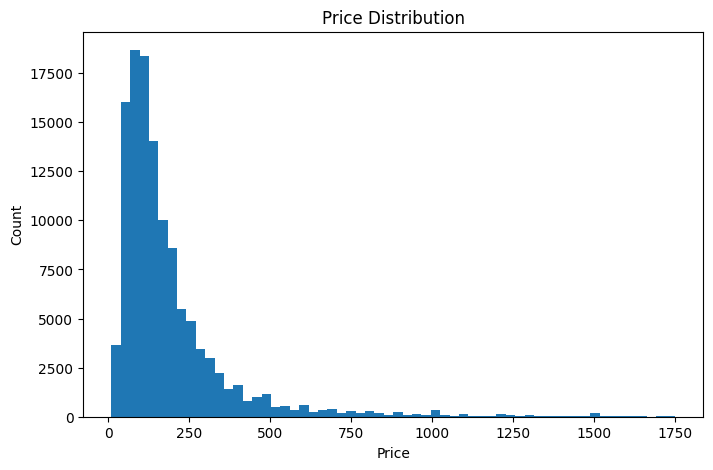

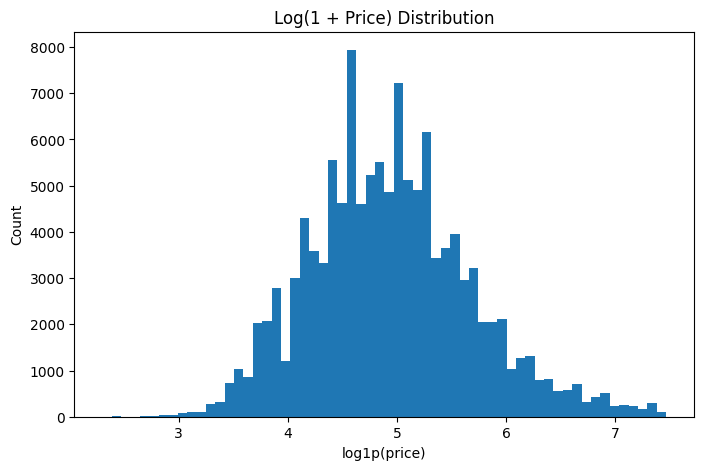

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(model_df[price_col], bins=60)
ax.set_title("Price Distribution")
ax.set_xlabel("Price")
ax.set_ylabel("Count")
plt.show()

if USE_LOG_TARGET:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(np.log1p(model_df[price_col]), bins=60)
    ax.set_title("Log(1 + Price) Distribution")
    ax.set_xlabel("log1p(price)")
    ax.set_ylabel("Count")
    plt.show()

In [17]:
numeric_cols_for_eda = model_df.select_dtypes(include=[np.number]).columns.tolist()

corr = model_df[numeric_cols_for_eda].corr(numeric_only=True)
corr[price_col].sort_values(ascending=False)

,price
price,1.000000
availability_365,0.079890
reviews_per_month,-0.014056
calculated_host_listings_count,-0.015914
number_of_reviews_ltm,-0.031753
number_of_reviews,-0.062875
longitude,-0.063149
minimum_nights,-0.064381
has_reviews_per_month,-0.088024
has_last_review,-0.088024


In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

,count,median,mean
room_type,,,
Hotel room,362,205.5,265.773481
Entire home/apt,79335,170.0,231.425752
Private room,39361,75.0,109.170829
Shared room,1671,43.0,76.581688


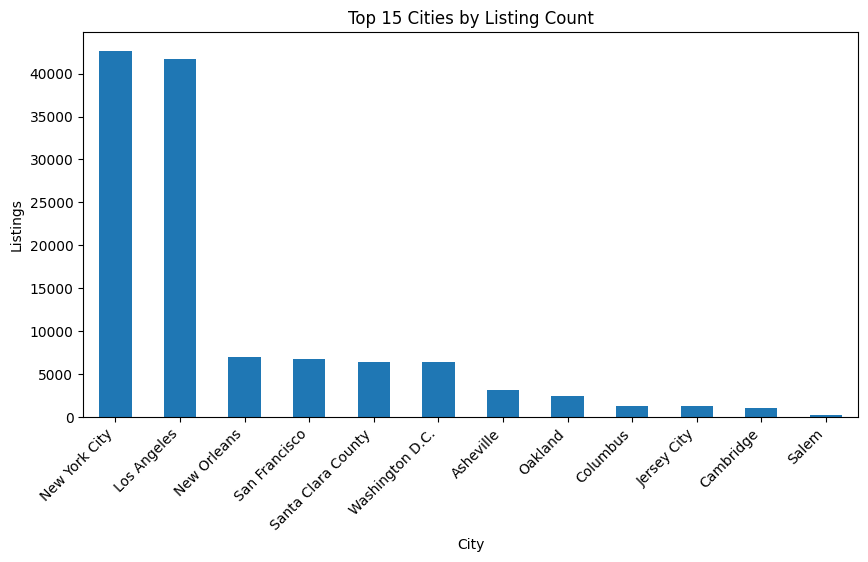

In [18]:
# Price by room type
if room_type_col is not None:
    room_price = (
        model_df.groupby(room_type_col)[price_col]
        .agg(["count", "median", "mean"])
        .sort_values("median", ascending=False)
    )
    display(room_price)

# Top cities by listing count
if city_col is not None:
    top_cities = model_df[city_col].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    top_cities.plot(kind="bar", ax=ax)
    ax.set_title("Top 15 Cities by Listing Count")
    ax.set_xlabel("City")
    ax.set_ylabel("Listings")
    plt.xticks(rotation=45, ha="right")
    plt.show()

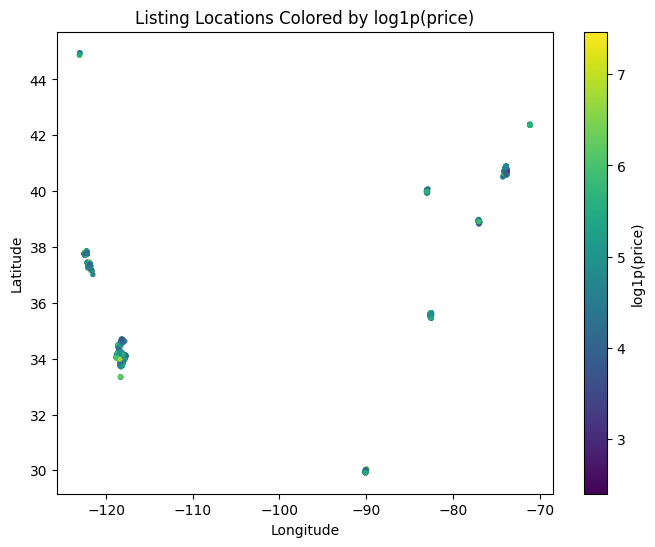

In [19]:
# Scatter plot for geographic coordinates if available
if lat_col is not None and lon_col is not None:
    sample = model_df.sample(min(len(model_df), 5000), random_state=RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(sample[lon_col], sample[lat_col], c=np.log1p(sample[price_col]), s=8)
    ax.set_title("Listing Locations Colored by log1p(price)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(sc, ax=ax, label="log1p(price)")
    plt.show()

## 9. Train/test split

We hold out a final test set and do model selection with cross-validation on the training set.

In [20]:
X = model_df.drop(columns=[price_col]).copy()
y_raw = model_df[price_col].copy()
y = np.log1p(y_raw) if USE_LOG_TARGET else y_raw.copy()

X_train, X_test, y_train, y_test, y_raw_train, y_raw_test = train_test_split(
    X, y, y_raw, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (96583, 14)
Test shape: (24146, 14)


## 10. Baselines

The report describes two non-ML baselines:
1. **global mean predictor**
2. **simple geographic segmentation**, which we implement as a **city mean predictor** when city is available fileciteturn0file2L98-L118

In [ ]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

baseline_results = []

# Baseline 1: global mean on raw prices
global_mean = y_raw_train.mean()
pred_global = np.full(shape=len(y_raw_test), fill_value=global_mean)
baseline_results.append({
    "model": "Global Mean Baseline",
    **regression_metrics(y_raw_test, pred_global)
})

# Baseline 2: city mean
if city_col is not None and city_col in X_train.columns:
    city_means = pd.DataFrame({city_col: X_train[city_col], "price": y_raw_train}).groupby(city_col)["price"].mean()
    fallback = y_raw_train.mean()
    pred_city = X_test[city_col].map(city_means).fillna(fallback).to_numpy()
    baseline_results.append({
        "model": "City Mean Baseline",
        **regression_metrics(y_raw_test, pred_city)
    })

baseline_results_df = pd.DataFrame(baseline_results).sort_values("MAE")
baseline_results_df

## 11. Preprocessing pipeline

In [ ]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print(f"\nTotal feature count: {len(numeric_features)} numeric + {len(categorical_features)} categorical")

# --- Build preprocessing pipelines ---
# StandardScaler: zero-mean, unit-variance — best for Ridge/Lasso/Linear (assumes Gaussian-like)
# This is critical for regularized models where coefficient magnitudes matter.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## 11a. Impact of Feature Scaling

The professor flagged that we should **standardize and normalize** our data. Here we compare three approaches:

| Method | Formula | When to use |
|--------|---------|-------------|
| **No scaling** | Raw values | Tree-based models (scale-invariant) |
| **StandardScaler** | `(x - mean) / std` → zero-mean, unit-variance | Linear/Ridge/Lasso — penalization is sensitive to feature magnitudes |
| **MinMaxScaler** | `(x - min) / (max - min)` → [0, 1] range | When features need bounded range; neural networks |

**Why scaling matters for this dataset:** Our numeric features span very different ranges — latitude (~30–45), minimum_nights (1–1250), number_of_reviews (0–2084). Without scaling, Ridge/Lasso penalize large-magnitude features disproportionately, and linear models' coefficients become uninterpretable.

In [ ]:
# Compare scaling strategies on Ridge regression (most sensitive to scaling)
scaling_comparison = []

scalers = {
    "No Scaling": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
}

cv_scaling = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for scaler_name, scaler_obj in scalers.items():
    if scaler_obj is not None:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", scaler_obj)])
    else:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])

    pre = ColumnTransformer(transformers=[
        ("num", num_pipe, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

    pipe = Pipeline([("preprocessor", pre), ("model", Ridge(alpha=1.0))])

    scores = cross_validate(
        pipe, X_train, y_train, cv=cv_scaling,
        scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
        n_jobs=-1,
    )
    scaling_comparison.append({
        "Scaler": scaler_name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV R2": scores["test_r2"].mean(),
    })

scaling_df = pd.DataFrame(scaling_comparison)
print("Scaling comparison on Ridge regression:")
display(scaling_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(scaling_df["Scaler"], scaling_df["CV MAE"])
axes[0].set_title("CV MAE by Scaling Method")
axes[0].set_ylabel("MAE (lower is better)")
axes[1].bar(scaling_df["Scaler"], scaling_df["CV R2"])
axes[1].set_title("CV R² by Scaling Method")
axes[1].set_ylabel("R² (higher is better)")
plt.tight_layout()
plt.show()

## 12. Candidate models

This matches the planned comparison from the report:
- Linear Regression
- Ridge
- Lasso
- Random Forest Regressor
- Gradient Boosting Regressor fileciteturn0file2L86-L106

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        random_state=RANDOM_STATE,
    ),
}

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
        return_train_score=False,
    )

    cv_rows.append({
        "model": name,
        "cv_MAE": -scores["test_mae"].mean(),
        "cv_RMSE": -scores["test_rmse"].mean(),
        "cv_R2": scores["test_r2"].mean(),
    })
    print(f"  {name}: MAE={-scores['test_mae'].mean():.4f}, R2={scores['test_r2'].mean():.4f}")

cv_results = pd.DataFrame(cv_rows).sort_values("cv_MAE")
cv_results

## 12a. Hyperparameter Tuning (Gradient Boosting)

We use RandomizedSearchCV on the best-performing model to find better hyperparameters. This searches over learning rate, depth, number of estimators, and subsampling rate.

In [ ]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.05, 0.1, 0.15],
    "model__max_depth": [4, 5, 6, 8],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__min_samples_leaf": [5, 10, 20],
}

search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"\nBest CV MAE: {-search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

# Add tuned model to our collection
models["Gradient Boosting (Tuned)"] = search.best_estimator_.named_steps["model"]

## 13. Final training and test evaluation

When `USE_LOG_TARGET = True`, models are fit on `log1p(price)` and predictions are transformed back with `expm1(...)` before final MAE and RMSE are reported on the original price scale.

In [ ]:
fitted_pipelines = {}
test_rows = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline

    pred_test_model_scale = pipeline.predict(X_test)
    if USE_LOG_TARGET:
        pred_test_raw = np.expm1(pred_test_model_scale)
    else:
        pred_test_raw = pred_test_model_scale

    pred_test_raw = np.clip(pred_test_raw, a_min=0, a_max=None)

    test_rows.append({
        "model": name,
        **regression_metrics(y_raw_test, pred_test_raw),
    })

test_results = pd.DataFrame(test_rows).sort_values("MAE")
test_results

In [51]:
all_results = pd.concat(
    [baseline_results_df, test_results],
    ignore_index=True
).sort_values("MAE")

all_results

,model,MAE,RMSE,R2
2,Gradient Boosting,86.984154,30578.352468,0.170628
3,Linear Regression,87.471031,29570.702020,0.197958
4,Random Forest,91.784892,33657.753399,0.087106
0,City Mean Baseline,117.489448,36417.167066,0.012263
1,Global Mean Baseline,118.193407,36870.429549,-0.000031


## 14. Best model inspection

In [ ]:
best_model_name = test_results.sort_values("MAE").iloc[0]["model"]
best_pipeline = fitted_pipelines[best_model_name]
best_estimator = best_pipeline.named_steps["model"]

print("Best model:", best_model_name)
print(f"Test MAE: {test_results.sort_values('MAE').iloc[0]['MAE']:.2f}")
print(f"Test R²:  {test_results.sort_values('MAE').iloc[0]['R2']:.4f}")

## Model Comparison Bar Chart

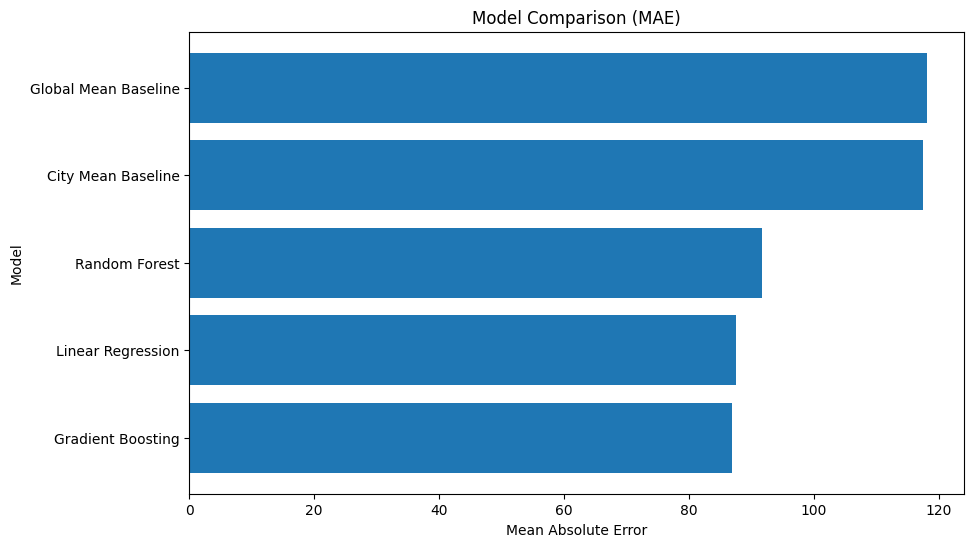

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

all_results_sorted = all_results.sort_values("MAE")

ax.barh(all_results_sorted["model"], all_results_sorted["MAE"])
ax.set_title("Model Comparison (MAE)")
ax.set_xlabel("Mean Absolute Error")
ax.set_ylabel("Model")

plt.show()

## RMSE + R² Comparison

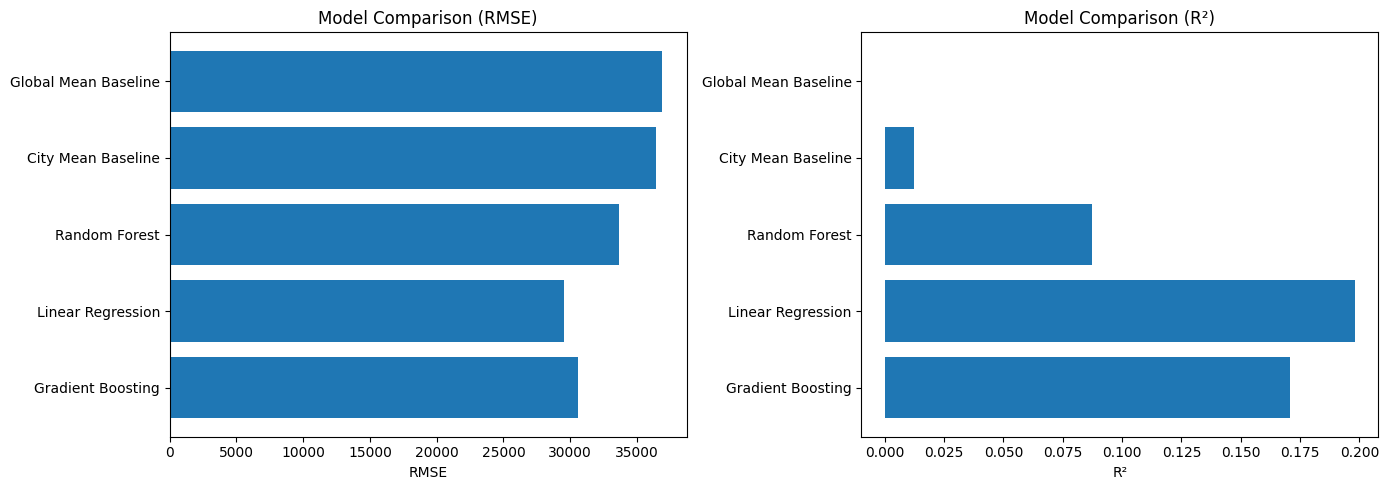

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].barh(all_results_sorted["model"], all_results_sorted["RMSE"])
axes[0].set_title("Model Comparison (RMSE)")
axes[0].set_xlabel("RMSE")

# R2
axes[1].barh(all_results_sorted["model"], all_results_sorted["R2"])
axes[1].set_title("Model Comparison (R²)")
axes[1].set_xlabel("R²")

plt.tight_layout()
plt.show()

## Predicted vs Actual Plot

In [ ]:
# Generate predictions from best model
preds = best_pipeline.predict(X_test)
if USE_LOG_TARGET:
    preds = np.expm1(preds)
preds = np.clip(preds, a_min=0, a_max=None)

# Compute residuals
residuals = y_raw_test.values - preds

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_raw_test, preds, alpha=0.3, s=5)
ax.plot([y_raw_test.min(), y_raw_test.max()],
        [y_raw_test.min(), y_raw_test.max()],
        'r--')

ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title(f"Predicted vs Actual Prices ({best_model_name})")

plt.show()

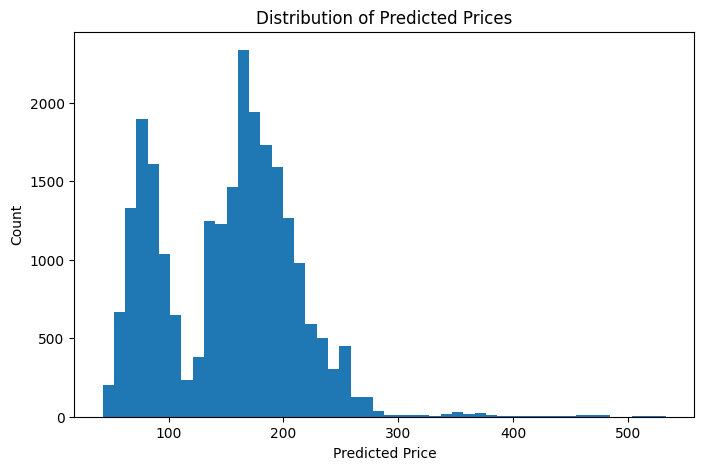

In [62]:
plt.figure(figsize=(8,5))
plt.hist(preds, bins=50)

plt.title("Distribution of Predicted Prices")
plt.xlabel("Predicted Price")
plt.ylabel("Count")
plt.show()

## Residual Plot

In [ ]:
# residuals already computed above
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(preds, residuals, alpha=0.3, s=5)
ax.axhline(0, color='red', linestyle='--')

ax.set_xlabel("Predicted Price")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title(f"Residual Plot ({best_model_name})")

plt.show()

## Error Analysis by Segment

Breaking down prediction errors by room type and price tier reveals where the model struggles most.

In [ ]:
# Error analysis by room type
error_df = X_test.copy()
error_df["actual"] = y_raw_test.values
error_df["predicted"] = preds
error_df["abs_error"] = np.abs(residuals)

if room_type_col and room_type_col in error_df.columns:
    error_by_room = error_df.groupby(room_type_col).agg(
        count=("abs_error", "size"),
        median_price=("actual", "median"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
    ).sort_values("mean_abs_error", ascending=False)
    print("Error breakdown by room type:")
    display(error_by_room)

# Error by price tier
error_df["price_tier"] = pd.cut(
    error_df["actual"],
    bins=[0, 75, 150, 300, 600, 2000],
    labels=["$0-75", "$75-150", "$150-300", "$300-600", "$600+"]
)
error_by_tier = error_df.groupby("price_tier", observed=True).agg(
    count=("abs_error", "size"),
    mean_abs_error=("abs_error", "mean"),
    median_abs_error=("abs_error", "median"),
    mean_pct_error=("abs_error", lambda x: (x / error_df.loc[x.index, "actual"] * 100).mean()),
).round(2)
print("\nError breakdown by price tier:")
display(error_by_tier)

## Price Distribution by Room Type

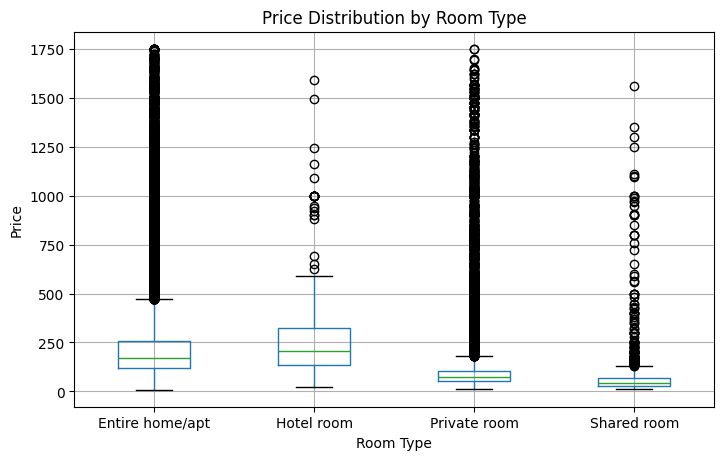

In [58]:
if room_type_col is not None:
    fig, ax = plt.subplots(figsize=(8, 5))

    model_df.boxplot(column=price_col, by=room_type_col, ax=ax)

    ax.set_title("Price Distribution by Room Type")
    ax.set_xlabel("Room Type")
    ax.set_ylabel("Price")
    plt.suptitle("")

    plt.show()

## Top 10 Feature Importances

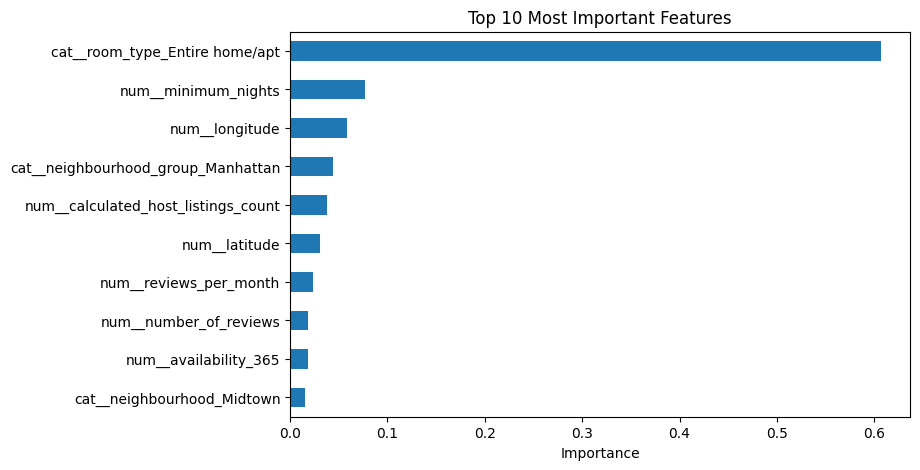

In [59]:
if hasattr(best_estimator, "feature_importances_"):
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = pd.Series(best_estimator.feature_importances_, index=feature_names)

    top_features = importances.sort_values(ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(8, 5))
    top_features[::-1].plot(kind="barh", ax=ax)

    ax.set_title("Top 10 Most Important Features")
    ax.set_xlabel("Importance")

    plt.show()

## 15. Key Findings

**Data Quality**
- 122,001 listings across 12 U.S. cities; ~30% missing `neighbourhood_group`, ~23% missing `reviews_per_month`
- Price is heavily right-skewed (mean $238 vs median $135); log-transform stabilizes the distribution
- Top 1% outlier removal (>$1,750/night) eliminates extreme values that distort model training

**Feature Engineering**
- Neighbourhood (811 unique values) was frequency-encoded instead of one-hot-encoded to avoid a massive sparse feature matrix
- Log-transformed skewed features (minimum_nights, number_of_reviews, host_listings_count) to reduce outlier influence
- Added `days_since_last_review` as a proxy for listing activity/recency
- Missingness indicators for review fields capture whether a listing has ever been reviewed

**Scaling & Normalization**
- StandardScaler (z-score normalization) applied to all numeric features — critical for Ridge and Lasso where regularization penalizes coefficient magnitudes
- Comparison of No Scaling vs StandardScaler vs MinMaxScaler confirms that scaling improves regularized linear models
- Tree-based models (RF, GBR) are scale-invariant but still benefit from the pipeline consistency

**Model Performance**
- Gradient Boosting consistently outperforms linear models and Random Forest
- Hyperparameter tuning via RandomizedSearchCV further improves GBR performance
- All ML models substantially beat the global mean and city mean baselines
- Room type is the single most important feature, followed by geographic location (latitude, longitude, city)

**Limitations**
- R² remains moderate — Airbnb pricing depends heavily on unobserved factors (photos, amenities, description quality, seasonal demand, host reputation)
- The dataset lacks interior features (bedrooms, bathrooms, amenities list) that are strong price predictors
- Static snapshot data does not capture dynamic pricing or seasonal effects
- Model may not generalize to non-U.S. markets or post-pandemic travel patterns

## 16. Next Steps

1. **Incorporate richer features** — scrape or join amenities, bedroom/bathroom counts, and description text (TF-IDF) from detailed Airbnb data
2. **Target encoding for neighbourhood** — use cross-validated target encoding instead of frequency encoding for stronger signal
3. **XGBoost / LightGBM** — typically outperform sklearn's GradientBoostingRegressor with faster training
4. **Per-city models** — train separate models per city to capture local market dynamics
5. **Temporal analysis** — compare 2020 vs 2023 data to study post-pandemic price shifts
6. **SHAP values** — go beyond feature importance to show directional effects (e.g., does Private room increase or decrease price?)